# Real World Classification

## Load data

Import the necessary libraries

In [16]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [18]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

missing_cols = df.columns[df.isnull().any()]
print(missing_cols)
stats = df[missing_cols].agg(['mean', 'std'])
print(stats)

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'BranchLength'],
      dtype='object')
      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
mean       6.320551      2.837472       5.085612      1.675732     16.302941
std        1.037115      0.389564       1.582807      0.706689      1.035228


## Data Preprocessing

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    
    imputer = KNNImputer()
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    
    # ---------- --------------------- ----------
     
    return df, feature_cols

df, feature_cols = data_preprocessing(df)
stats = df[missing_cols].agg(['mean', 'std'])
print(stats)

      SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  BranchLength
mean       6.319840      2.837040       5.049883      1.684440     16.303440
std        1.009275      0.372434       1.514955      0.694645      1.011012


In [20]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

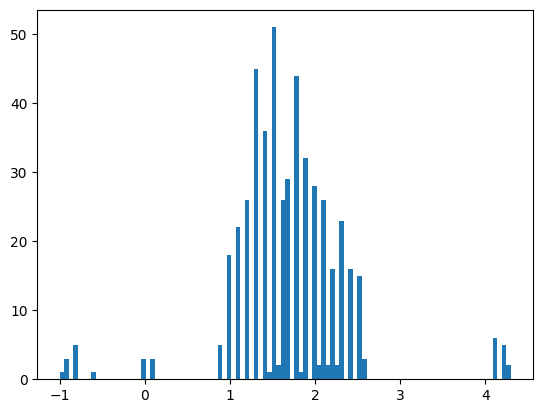

Top 5 most negative:
SepalWidthMajorAxis: -0.09635042983649401
SepalGlossIndex: -0.09520000072196652
SepalWidthCompactness: -0.0884963955916379
SepalWidthCurvature: -0.0813343822833098
SepalWidthMinorAxis: -0.07439241023821906
most positive feature: PetalWidthCompactness
['PetalWidthCompactness', 'SepalWidthMajorAxis', 'SepalGlossIndex', 'SepalWidthCompactness', 'SepalWidthCurvature', 'SepalWidthMinorAxis']


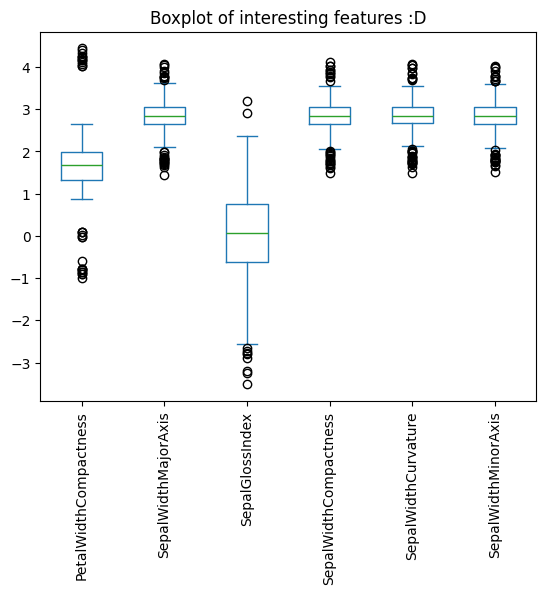

In [ ]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
import matplotlib.pyplot as plt
df = pd.read_csv('data/NYCU_Iris.csv')
df, feature_cols = data_preprocessing(df)
plt.hist(df['PetalWidthCm'], bins=100)
plt.show()

petal_col = df['PetalWidthCm']
exclude_cols = ['PetalWidthCm','Species', 'Id']
df2 = df.drop(columns=exclude_cols)

corr = r_regression(df2, petal_col)

corr_dict = dict(zip(df2.columns, corr))
sort_corr_neg = sorted(corr_dict.items(), key=lambda x: x[1])
sort_corr_pos = sorted(corr_dict.items(), key=lambda x: x[1], reverse=True)

five_most_negative = sort_corr_neg[:5]
print('Top 5 most negative:')
for feature, value in five_most_negative:
    print(f'{feature}: {value}')


most_positive = sort_corr_pos[:1]
print('most positive feature:', most_positive[0][0])
features = []
features.append(most_positive[0][0])
for pair in five_most_negative:
    if pair[0] not in features:
        features.append(pair[0])
5

print(features)
df2[features].plot(kind='box')
plt.title('Boxplot of interesting features :D') 
plt.xticks(rotation=90)
plt.show()


## Model Training

### Prepare the data

In [22]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0
        
X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,0.452830,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,0.471698,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,0.471698,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,0.433962,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,0.471698,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

50. Training loss: 0.6183886535310102, Val loss:0.638338191177124
100. Training loss: 0.5960033921480784, Val loss:0.6229857283892483
150. Training loss: 0.5781690886526527, Val loss:0.611179684417757
200. Training loss: 0.5636439627476498, Val loss:0.6019785825360592
250. Training loss: 0.5515861130769195, Val loss:0.5947349187857767
300. Training loss: 0.5414115554176107, Val loss:0.5889917649142379
350. Training loss: 0.5327055446405081, Val loss:0.5844187428740432
400. Training loss: 0.5251667000245236, Val loss:0.5807716266567299
450. Training loss: 0.5185712433977272, Val loss:0.5778662753932695
500. Training loss: 0.5127496761323889, Val loss:0.5755614147648994
550. Training loss: 0.5075712624849853, Val loss:0.5737469965121451
600. Training loss: 0.5029334978289509, Val loss:0.5723361523089564
650. Training loss: 0.49875481918863024, Val loss:0.571259514930716
700. Training loss: 0.4949694641429734, Val loss:0.5704611319860384
750. Training loss: 0.49152377948438897, Val loss:0

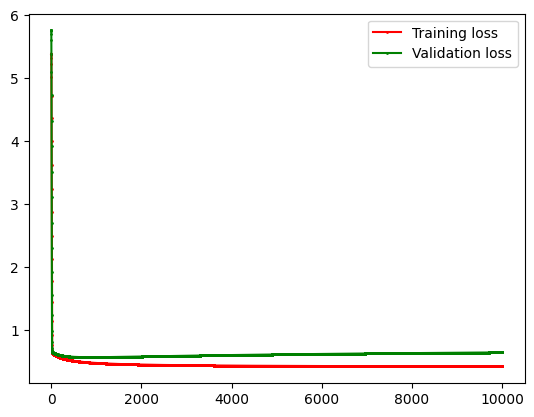

50. Training loss: 0.6572929744907086, Val loss:0.6699828194400217
100. Training loss: 0.622637070859397, Val loss:0.6436662386803186
150. Training loss: 0.5968724567755489, Val loss:0.6248125819822072
200. Training loss: 0.5771051326187799, Val loss:0.6109911766151703
250. Training loss: 0.5614967431436563, Val loss:0.6006595362014496
300. Training loss: 0.5488615550371709, Val loss:0.592816880200311
350. Training loss: 0.5384146721109381, Val loss:0.5867951648523864
400. Training loss: 0.5296214516465223, Val loss:0.5821354839154358
450. Training loss: 0.5221074045422048, Val loss:0.5785140918733357
500. Training loss: 0.5156033285344713, Val loss:0.575697079625259
550. Training loss: 0.5099110923718569, Val loss:0.5735118491814875
600. Training loss: 0.5048817498726621, Val loss:0.5718286705532784
650. Training loss: 0.5004011866212237, Val loss:0.5705484476177356
700. Training loss: 0.4963804805267807, Val loss:0.5695944073134431
750. Training loss: 0.4927492828335417, Val loss:0.5

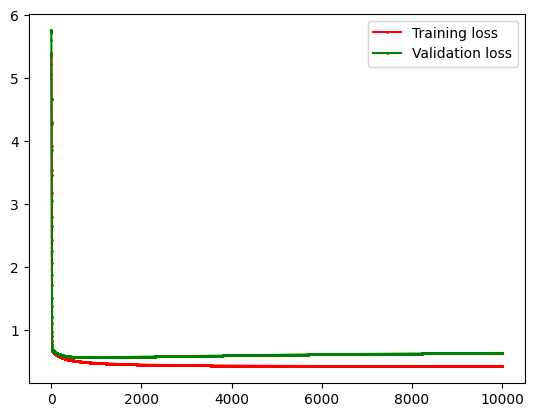

50. Training loss: 0.6452697086773239, Val loss:0.6968499479311139
100. Training loss: 0.6153173263140874, Val loss:0.6719782500846729
150. Training loss: 0.59325485740718, Val loss:0.6536696477271114
200. Training loss: 0.5764684844088152, Val loss:0.6397841003205789
250. Training loss: 0.5633341200711531, Val loss:0.6289858433210878
300. Training loss: 0.5528129684290483, Val loss:0.6204131091021731
350. Training loss: 0.5442189898190924, Val loss:0.6134905669590573
400. Training loss: 0.5370846002714735, Val loss:0.6078214808718364
450. Training loss: 0.5310815475661984, Val loss:0.6031241242404519
500. Training loss: 0.5259730833692304, Val loss:0.5991931727748395
550. Training loss: 0.5215842530460945, Val loss:0.5958755490412051
600. Training loss: 0.5177829333574684, Val loss:0.5930548613647986
650. Training loss: 0.5144674105312012, Val loss:0.590641097826212
700. Training loss: 0.5115580398256521, Val loss:0.5885636218253685
750. Training loss: 0.5089915147958207, Val loss:0.5

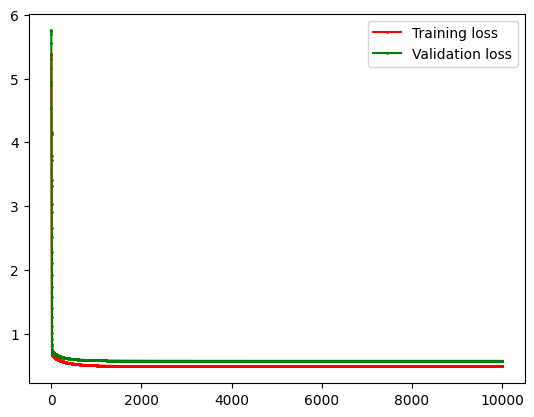

50. Training loss: 0.6737677137734904, Val loss:0.6834214016028082
100. Training loss: 0.674727623297248, Val loss:0.6839193599615129
150. Training loss: 0.6747482653009459, Val loss:0.6839296424333314
200. Training loss: 0.6747487082172127, Val loss:0.6839298511808398
250. Training loss: 0.6747487177711811, Val loss:0.683929855384003
300. Training loss: 0.6747487179783244, Val loss:0.6839298554676928
350. Training loss: 0.6747487179828373, Val loss:0.683929855469333
400. Training loss: 0.6747487179829359, Val loss:0.6839298554693647
450. Training loss: 0.6747487179829381, Val loss:0.683929855469365
500. Training loss: 0.6747487179829382, Val loss:0.683929855469365
550. Training loss: 0.6747487179829382, Val loss:0.683929855469365
600. Training loss: 0.6747487179829382, Val loss:0.683929855469365
650. Training loss: 0.6747487179829382, Val loss:0.683929855469365
700. Training loss: 0.6747487179829382, Val loss:0.683929855469365
750. Training loss: 0.6747487179829382, Val loss:0.6839298

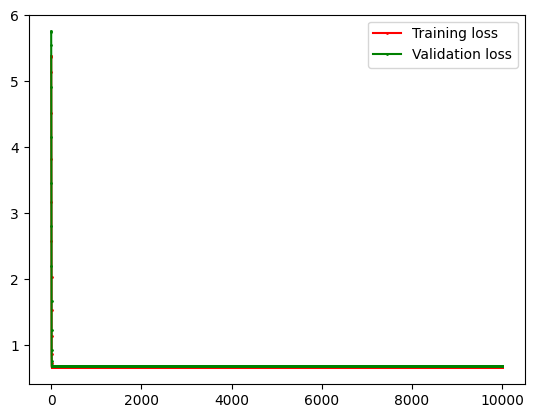

dict_keys(['model_lambda_0', 'model_lambda_0.01', 'model_lambda_1', 'model_lambda_100'])


In [23]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad

np.random.seed(seed)
'''
model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='', reg_lambda=0.0)

# print model parameters
print("Model parameters (weights):", model.W)
# sum of absolute values of weights
print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))
'''

models = {}
reg_lambda_list = [0.01, 1, 100]
models['model_lambda_0'] = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
models['model_lambda_0'].fit(X_train, y_train,lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='', reg_lambda=0.0)

for reg_lambda in reg_lambda_list:
    models[f'model_lambda_{reg_lambda}'] = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
    models[f'model_lambda_{reg_lambda}'].fit(X_train, y_train, lr=0.1, n_iteration=10000, val_ratio=0.2, reg_type='l2', reg_lambda=reg_lambda)
print(models.keys())


## Metrics

Model:  model_lambda_0
Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


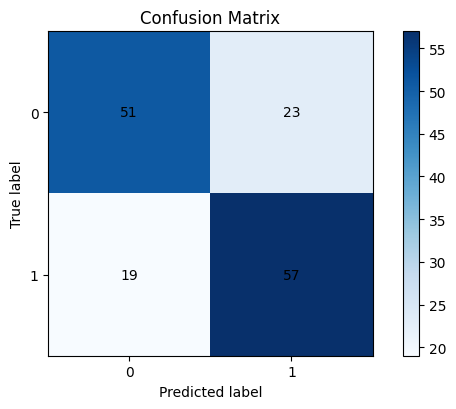

Model:  model_lambda_0.01
Model Evaluation
Accuracy  : 0.7200
Precision : 0.7125
Recall    : 0.7500
F1-score  : 0.7308


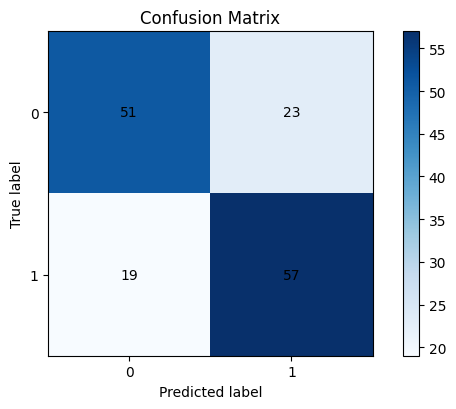

Model:  model_lambda_1
Model Evaluation
Accuracy  : 0.7400
Precision : 0.7342
Recall    : 0.7632
F1-score  : 0.7484


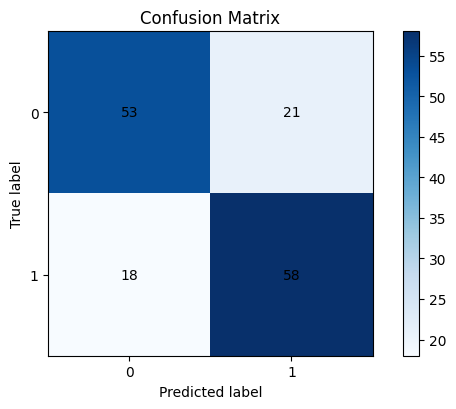

Model:  model_lambda_100
Model Evaluation
Accuracy  : 0.5067
Precision : 0.5067
Recall    : 1.0000
F1-score  : 0.6726


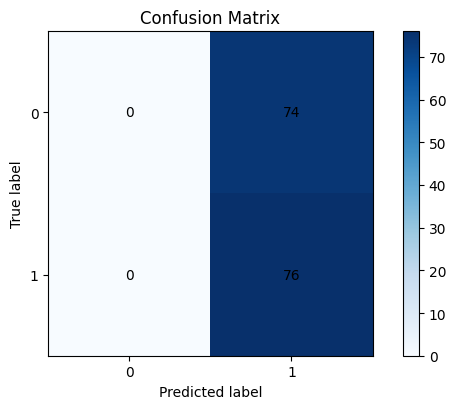

In [24]:
# use evaluate_binary_classifier to evaluate the model on the test set
from model.metrics import evaluate_binary_classifier

#y_pred = model.predict(X_test)
#evaluate_binary_classifier(y_test, y_pred)

for item in models.items():
    name, model = item
    y_pred = model.predict(X_test)
    print("Model: ", name)
    evaluate_binary_classifier(y_test, y_pred)